# Role Adherence — Scoring Method Comparison

Compares deterministic scoring methods vs LLM-as-a-judge for binary role adherence detection.

**Deterministic methods** (BERTScore, Cosine, Mahalanobis, KL Divergence): return a continuous
similarity score — they do not classify. We report mean score per label group (adherent vs violation)
and the separation between groups.

**LLM judge**: returns a binary decision (YES/NO). We report F1 macro and Cohen's κ with
95% bootstrap confidence intervals.

Three dataset size conditions: n=15 / n=50 / n=150.

In [40]:
!pip install -q bert-score sentence-transformers transformers torch groq python-dotenv scikit-learn matplotlib seaborn numpy scipy

In [41]:
import json
import os
import warnings
from collections import Counter
from pathlib import Path

from dotenv import load_dotenv
load_dotenv(Path(__file__).parent / ".env" if "__file__" in dir() else ".env")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    f1_score, cohen_kappa_score, confusion_matrix,
    roc_auc_score, average_precision_score, classification_report,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [42]:
BENCHMARK_PATH = "benchmark.json"
with open(BENCHMARK_PATH, encoding="utf-8") as f:
    data = json.load(f)

gold_all   = [1 if d["label"] == "adherent" else 0 for d in data]
labels_all = [d["label"] for d in data]

CONDITIONS = {"n=15": 15, "n=50": 50, "n=150": 150}
cond_names = list(CONDITIONS.keys())

print(f"Loaded {len(data)} turns")
print("Label distribution:", Counter(d["label"] for d in data))

Loaded 150 turns
Label distribution: Counter({'adherent': 60, 'scope_violation': 30, 'tone_violation': 30, 'constructive_failure': 30})


## Scoring Methods

In [43]:
# ── BERTScore ────────────────────────────────────────────────────────────────
from bert_score import score as bert_score_fn

def score_bertscore(records):
    candidates = [r["assistant"] for r in records]
    references = [r["ground_truth_assistant"] for r in records]
    _, _, F1 = bert_score_fn(candidates, references, lang="en", verbose=False)
    return F1.tolist()

print("BERTScore scorer ready")

BERTScore scorer ready


In [44]:
# ── Cosine similarity (sentence-transformers) ─────────────────────────────────
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

_embed_model = SentenceTransformer("all-MiniLM-L6-v2")

def embed(texts):
    return _embed_model.encode(texts, show_progress_bar=False, normalize_embeddings=True)

def score_cosine(records):
    cand_embs = embed([r["assistant"] for r in records])
    ref_embs  = embed([r["ground_truth_assistant"] for r in records])
    sims = (cand_embs * ref_embs).sum(axis=1)  # dot product of normalized = cosine
    return sims.tolist()

print("Cosine scorer ready")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cosine scorer ready


In [45]:
# ── NLI ──────────────────────────────────────────────────────────────────────
from transformers import pipeline

_nli = pipeline("zero-shot-classification", model="facebook/bart-large-mnli",
                device=-1, framework="pt")

def score_nli(records):
    """Returns 0.0 for contradiction (violation), 1.0 otherwise."""
    scores = []
    for r in records:
        result = _nli(r["assistant"],
                      candidate_labels=["consistent", "neutral", "contradiction"],
                      hypothesis_template="This text {} with: " + r["ground_truth_assistant"])
        top_label = result["labels"][0]
        scores.append(0.0 if top_label == "contradiction" else 1.0)
    return scores

print("NLI scorer ready")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

NLI scorer ready


In [46]:
# ── Mahalanobis Distance ──────────────────────────────────────────────────────
LAMBDA_REG = 0.01  # L2 regularisation

def score_mahalanobis(records, n_gt):
    """
    Builds the role distribution from the first n_gt ground-truth embeddings,
    then scores all records. Score = exp(-dist / median_dist), so the median
    candidate sits at exp(-1) ≈ 0.37; closer → higher, farther → lower.
    """
    gt_texts = [r["ground_truth_assistant"] for r in records[:n_gt]]
    gt_embs  = embed(gt_texts)  # (n_gt, d)

    mu   = gt_embs.mean(axis=0)
    diag = gt_embs.var(axis=0) + LAMBDA_REG   # diagonal cov + regularisation
    VI   = np.diag(1.0 / diag)                # inverse of diagonal cov

    cand_embs = embed([r["assistant"] for r in records])
    dists = np.array([mahalanobis(x, mu, VI) for x in cand_embs])

    # normalise by median distance so scores live in (0, 1) around ≈0.37
    median_dist = np.median(dists)
    scores = np.exp(-dists / (median_dist + 1e-9))
    return scores.tolist()

print("Mahalanobis scorer ready")

Mahalanobis scorer ready


In [47]:
# ── KL Divergence ─────────────────────────────────────────────────────────────
TOP_K_VOCAB = 500
N_MIN_KL    = 1

def tokenize(text):
    return text.lower().split()

def build_vocab_dist(texts, vocab):
    counts = {w: 1 for w in vocab}  # Laplace smoothing
    for t in texts:
        for w in tokenize(t):
            if w in counts:
                counts[w] += 1
    total = sum(counts.values())
    return np.array([counts[w] / total for w in vocab])

def score_kl(records, n_gt):
    if n_gt < N_MIN_KL:
        return None

    gt_texts = [r["ground_truth_assistant"] for r in records[:n_gt]]

    # build vocabulary from top-k tokens in ground truth
    all_tokens = [w for t in gt_texts for w in tokenize(t)]
    vocab = [w for w, _ in Counter(all_tokens).most_common(TOP_K_VOCAB)]

    P = build_vocab_dist(gt_texts, vocab)  # role reference distribution

    scores = []
    for r in records:
        Q = build_vocab_dist([r["assistant"]], vocab)
        kl = entropy(P, Q)  # KL(P || Q)
        scores.append(float(np.exp(-kl)))
    return scores

print("KL Divergence scorer ready")

KL Divergence scorer ready


In [48]:
# ── PCA + Mahalanobis ─────────────────────────────────────────────────────────
PCA_COMPONENTS = 32

def score_pca_mahalanobis(records, n_gt):
    gt_texts = [r["ground_truth_assistant"] for r in records[:n_gt]]
    gt_embs  = embed(gt_texts)

    n_comp  = min(PCA_COMPONENTS, n_gt - 1)
    pca     = PCA(n_components=n_comp)
    gt_red  = pca.fit_transform(gt_embs)

    mu   = gt_red.mean(axis=0)
    diag = gt_red.var(axis=0) + LAMBDA_REG
    VI   = np.diag(1.0 / diag)

    cand_red    = pca.transform(embed([r["assistant"] for r in records]))
    dists       = np.array([mahalanobis(x, mu, VI) for x in cand_red])
    median_dist = np.median(dists)
    return np.exp(-dists / (median_dist + 1e-9)).tolist()


# ── k-NN (k=1, cosine proximity) ──────────────────────────────────────────────
KNN_K = 1

def score_knn(records, n_gt):
    gt_embs   = embed([r["ground_truth_assistant"] for r in records[:n_gt]])
    cand_embs = embed([r["assistant"] for r in records])
    knn = NearestNeighbors(n_neighbors=KNN_K, metric="cosine")
    knn.fit(gt_embs)
    distances, _ = knn.kneighbors(cand_embs)
    return (1 - distances.flatten()).tolist()


print("PCA+Mahalanobis and k-NN scorers ready")

PCA+Mahalanobis and k-NN scorers ready


In [49]:
# ── LLM Judge (Groq — llama-3.3-70b-versatile) ───────────────────────────────
from groq import Groq

_groq_client = Groq()  # reads GROQ_API_KEY from env

JUDGE_MODEL = "llama-3.3-70b-versatile"

JUDGE_SYSTEM = (
    "You are an evaluation assistant. Given a role definition and an assistant response, "
    "determine whether the response adheres to the role. "
    "Answer ONLY with YES (adherent) or NO (non-adherent)."
)

def judge_turn(role, assistant):
    msg = _groq_client.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user",   "content": f"ROLE:\n{role}\n\nASSISTANT RESPONSE:\n{assistant}"},
        ],
        max_tokens=5,
        temperature=0,
    )
    return 1 if "YES" in msg.choices[0].message.content.upper() else 0

def score_llm_judge(records):
    return [judge_turn(r["role"], r["assistant"]) for r in records]

print(f"LLM judge ready ({JUDGE_MODEL}, temperature=0)")

LLM judge ready (llama-3.3-70b-versatile, temperature=0)


## Analysis

In [50]:
def evaluate_binary(preds, gold):
    f1    = f1_score(gold, preds, average="macro", zero_division=0)
    kappa = cohen_kappa_score(gold, preds)
    return round(f1, 3), round(kappa, 3)

def mean_by_label(scores, gold, label):
    vals = [s for s, g in zip(scores, gold) if g == label]
    return round(float(np.mean(vals)), 3) if vals else None

def auc_ap(scores, gold):
    auc = roc_auc_score(gold, scores)
    ap  = average_precision_score(gold, scores)
    return round(auc, 3), round(ap, 3)

print("Helpers ready")

Helpers ready


In [51]:
# Pre-compute embeddings and scores for all 150 turns (reuse across conditions)
print("Computing BERTScore...")
bert_scores_all = score_bertscore(data)

print("Computing cosine similarity...")
cosine_scores_all = score_cosine(data)

print("Computing NLI...")
nli_scores_all = score_nli(data)

print("Running LLM judge...")
llm_preds_all = score_llm_judge(data)

print("Done.")

Computing BERTScore...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Computing cosine similarity...
Computing NLI...
Running LLM judge...
Done.


In [52]:
DET_METHODS  = ["BERTScore", "Cosine", "Mahalanobis", "KL Divergence"]  # used in Figure 1
CONT_METHODS = ["BERTScore", "Cosine", "Mahalanobis", "KL Divergence", "PCA+Mahalanobis", "k-NN"]
BIN_METHODS  = ["NLI", "LLM Judge"]

cont_results = {}
bin_results  = {}

for cname, n in CONDITIONS.items():
    gold   = gold_all[:n]
    subset = data[:n]

    for method, scores in [("BERTScore", bert_scores_all[:n]),
                            ("Cosine",    cosine_scores_all[:n])]:
        adh  = mean_by_label(scores, gold, 1)
        viol = mean_by_label(scores, gold, 0)
        auc, ap = auc_ap(scores, gold)
        cont_results.setdefault(method, {})[cname] = {
            "adherent": adh, "violation": viol,
            "separation": round(adh - viol, 3), "auc": auc, "ap": ap,
        }

    for method, scorer in [("Mahalanobis",      score_mahalanobis),
                            ("PCA+Mahalanobis",  score_pca_mahalanobis),
                            ("k-NN",             score_knn)]:
        scores = scorer(subset, n)
        if scores:
            adh  = mean_by_label(scores, gold, 1)
            viol = mean_by_label(scores, gold, 0)
            auc, ap = auc_ap(scores, gold)
            cont_results.setdefault(method, {})[cname] = {
                "adherent": adh, "violation": viol,
                "separation": round(adh - viol, 3), "auc": auc, "ap": ap,
            }

    kl = score_kl(subset, n)
    if kl:
        adh  = mean_by_label(kl, gold, 1)
        viol = mean_by_label(kl, gold, 0)
        auc, ap = auc_ap(kl, gold)
        cont_results.setdefault("KL Divergence", {})[cname] = {
            "adherent": adh, "violation": viol,
            "separation": round(adh - viol, 3), "auc": auc, "ap": ap,
        }

    for method, preds in [("NLI",       [int(s) for s in nli_scores_all[:n]]),
                           ("LLM Judge", llm_preds_all[:n])]:
        report = classification_report(
            gold, preds,
            labels=[0, 1], target_names=["violation", "adherent"],
            output_dict=True, zero_division=0,
        )
        bin_results.setdefault(method, {})[cname] = {
            "f1_adherent":  round(report["adherent"]["f1-score"],  3),
            "f1_violation": round(report["violation"]["f1-score"], 3),
            "f1_macro":     round(report["macro avg"]["f1-score"], 3),
            "kappa":        round(cohen_kappa_score(gold, preds),  3),
        }

sim_results = cont_results  # Figure 1 alias

print("=== Continuous Methods — Adherent / Violation / Separation / AUC / AP ===")
for method in CONT_METHODS:
    print(f"\n{method}")
    for cname in cond_names:
        v = cont_results.get(method, {}).get(cname)
        if v:
            print(f"  {cname}: adh={v['adherent']:.3f}  viol={v['violation']:.3f}  "
                  f"sep={v['separation']:+.3f}  AUC={v['auc']:.3f}  AP={v['ap']:.3f}")

print("\n=== Binary Methods — F1 per class / κ ===")
for method in BIN_METHODS:
    print(f"\n{method}")
    for cname in cond_names:
        v = bin_results.get(method, {}).get(cname)
        if v:
            print(f"  {cname}: F1_adh={v['f1_adherent']:.3f}  "
                  f"F1_viol={v['f1_violation']:.3f}  "
                  f"F1_macro={v['f1_macro']:.3f}  κ={v['kappa']:.3f}")

=== Continuous Methods — Adherent / Violation / Separation / AUC / AP ===

BERTScore
  n=15: adh=0.941  viol=0.864  sep=+0.077  AUC=1.000  AP=1.000
  n=50: adh=0.940  viol=0.869  sep=+0.071  AUC=1.000  AP=1.000
  n=150: adh=0.941  viol=0.868  sep=+0.073  AUC=0.995  AP=0.994

Cosine
  n=15: adh=0.905  viol=0.466  sep=+0.439  AUC=1.000  AP=1.000
  n=50: adh=0.902  viol=0.520  sep=+0.382  AUC=0.998  AP=0.998
  n=150: adh=0.877  viol=0.497  sep=+0.380  AUC=0.994  AP=0.990

Mahalanobis
  n=15: adh=0.404  viol=0.348  sep=+0.056  AUC=0.963  AP=0.948
  n=50: adh=0.391  viol=0.348  sep=+0.043  AUC=0.872  AP=0.762
  n=150: adh=0.391  viol=0.350  sep=+0.041  AUC=0.856  AP=0.761

KL Divergence
  n=15: adh=0.860  viol=0.858  sep=+0.002  AUC=0.537  AP=0.465
  n=50: adh=0.693  viol=0.671  sep=+0.022  AUC=0.870  AP=0.857
  n=150: adh=0.517  viol=0.494  sep=+0.023  AUC=0.877  AP=0.856

PCA+Mahalanobis
  n=15: adh=0.283  viol=0.419  sep=-0.136  AUC=0.000  AP=0.266
  n=50: adh=0.318  viol=0.393  sep=-0.0

## Figure 1 — Mean Similarity Score: Adherent vs Violation

In [53]:
import pathlib
FIGURES_DIR = pathlib.Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures → {FIGURES_DIR.resolve()}")

Figures → /Users/frino/Desktop/Alquimia/Gaussia/gaussia-papers/papers/Role_Adherence/figures


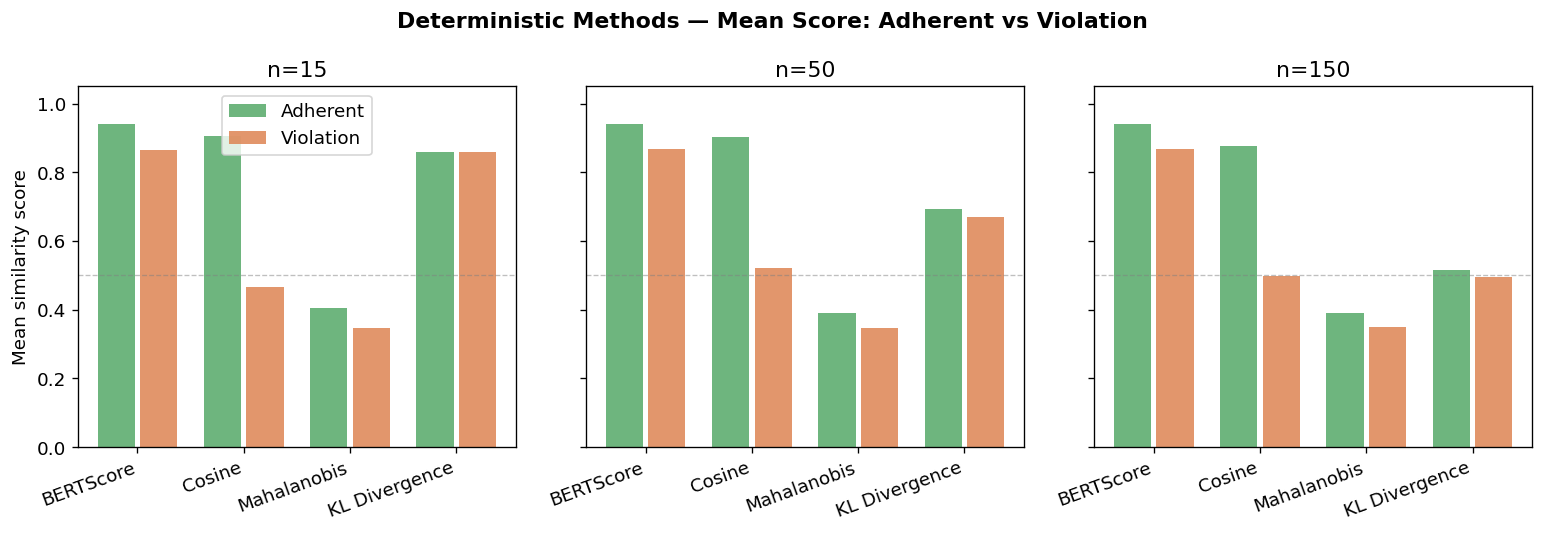

Saved ../figures/fig1_similarity_by_label.pdf


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

for ax, cname in zip(axes, cond_names):
    avail = [m for m in DET_METHODS if cname in sim_results.get(m, {})]
    x     = np.arange(len(avail))
    adh   = [sim_results[m][cname]["adherent"]  for m in avail]
    viol  = [sim_results[m][cname]["violation"] for m in avail]

    ax.bar(x - 0.2, adh,  0.35, label="Adherent",  color="#55A868", alpha=0.85)
    ax.bar(x + 0.2, viol, 0.35, label="Violation", color="#DD8452", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(avail, rotation=20, ha="right")
    ax.set_title(cname)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, ls="--", lw=0.8, color="gray", alpha=0.5)
    if ax is axes[0]:
        ax.set_ylabel("Mean similarity score")
        ax.legend()

fig.suptitle("Deterministic Methods — Mean Score: Adherent vs Violation", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig1_similarity_by_label.pdf", bbox_inches="tight")
plt.show()
print(f"Saved {FIGURES_DIR / 'fig1_similarity_by_label.pdf'}")

## Figure 2 — Separation vs Sample Size (Mahalanobis, KL Divergence, PCA+Mahalanobis)

In [55]:
n_values        = [15, 20, 30, 40, 50, 75, 100, 125, 150]
mh_sep_curve    = []
kl_sep_curve    = []
pca_mh_sep_curve = []

for n in n_values:
    subset = data[:n]
    gold   = gold_all[:n]

    mh = score_mahalanobis(subset, n)
    mh_sep_curve.append(
        round(mean_by_label(mh, gold, 1) - mean_by_label(mh, gold, 0), 3) if mh else None
    )

    kl = score_kl(subset, n)
    kl_sep_curve.append(
        round(mean_by_label(kl, gold, 1) - mean_by_label(kl, gold, 0), 3) if kl else None
    )

    pca_mh = score_pca_mahalanobis(subset, n)
    pca_mh_sep_curve.append(
        round(mean_by_label(pca_mh, gold, 1) - mean_by_label(pca_mh, gold, 0), 3)
    )

print("n:                      ", n_values)
print("Mahalanobis separation: ", mh_sep_curve)
print("KL separation:          ", kl_sep_curve)
print("PCA+Maha separation:    ", pca_mh_sep_curve)

n:                       [15, 20, 30, 40, 50, 75, 100, 125, 150]
Mahalanobis separation:  [0.056, 0.054, 0.055, 0.047, 0.043, 0.044, 0.039, 0.041, 0.041]
KL separation:           [0.002, 0.01, 0.02, 0.019, 0.022, 0.02, 0.022, 0.024, 0.023]
PCA+Maha separation:     [-0.136, -0.105, -0.082, -0.083, -0.075, -0.057, -0.049, -0.049, -0.04]


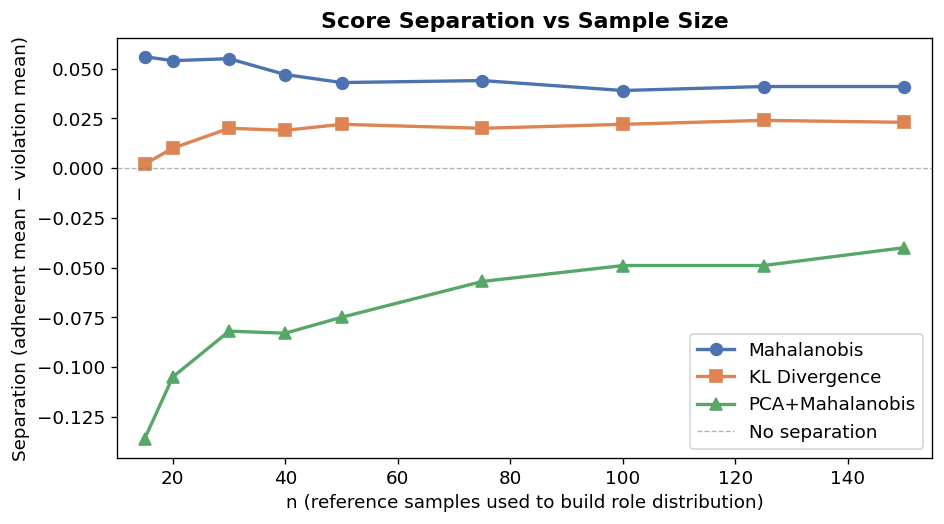

Saved ../figures/fig2_separation_curve.pdf


In [56]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for curve, label, color, marker in [
    (mh_sep_curve,     "Mahalanobis",      "#4C72B0", "o"),
    (kl_sep_curve,     "KL Divergence",    "#DD8452", "s"),
    (pca_mh_sep_curve, "PCA+Mahalanobis",  "#55A868", "^"),
]:
    valid_n = [n for n, v in zip(n_values, curve) if v is not None]
    valid_v = [v for v in curve if v is not None]
    ax.plot(valid_n, valid_v, marker=marker, color=color, label=label, lw=2, ms=7)

ax.axhline(0, ls="--", lw=0.8, color="gray", alpha=0.6, label="No separation")
ax.set_xlabel("n (reference samples used to build role distribution)")
ax.set_ylabel("Separation (adherent mean − violation mean)")
ax.set_title("Score Separation vs Sample Size", fontweight="bold")
ax.legend()
ax.set_xlim(10, 155)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig2_separation_curve.pdf", bbox_inches="tight")
plt.show()
print(f"Saved {FIGURES_DIR / 'fig2_separation_curve.pdf'}")

## Figure 3 — LLM Judge: F1 with 95% Bootstrap CI

In [57]:
N_BOOTSTRAP  = 1000
RANDOM_STATE = 42

def bootstrap_f1_kappa(y_true, y_pred, n_iter=N_BOOTSTRAP, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    f1s, ks, f1s_adh, f1s_viol = [], [], [], []
    for _ in range(n_iter):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        yt  = [y_true[i] for i in idx]
        yp  = [y_pred[i] for i in idx]
        if len(set(yt)) < 2:
            continue
        f1s.append(f1_score(yt, yp, average="macro", zero_division=0))
        ks.append(cohen_kappa_score(yt, yp))
        rep = classification_report(yt, yp, labels=[0, 1],
                                    target_names=["violation", "adherent"],
                                    output_dict=True, zero_division=0)
        f1s_adh.append(rep["adherent"]["f1-score"])
        f1s_viol.append(rep["violation"]["f1-score"])
    return {
        "f1_mean":       round(np.mean(f1s), 3),
        "f1_lo":         round(np.percentile(f1s, 2.5), 3),
        "f1_hi":         round(np.percentile(f1s, 97.5), 3),
        "k_mean":        round(np.mean(ks), 3),
        "k_lo":          round(np.percentile(ks, 2.5), 3),
        "k_hi":          round(np.percentile(ks, 97.5), 3),
        "f1_adh_mean":   round(np.mean(f1s_adh), 3),
        "f1_adh_lo":     round(np.percentile(f1s_adh, 2.5), 3),
        "f1_adh_hi":     round(np.percentile(f1s_adh, 97.5), 3),
        "f1_viol_mean":  round(np.mean(f1s_viol), 3),
        "f1_viol_lo":    round(np.percentile(f1s_viol, 2.5), 3),
        "f1_viol_hi":    round(np.percentile(f1s_viol, 97.5), 3),
    }

llm_ci = {}
for cname, n in CONDITIONS.items():
    llm_ci[cname] = bootstrap_f1_kappa(gold_all[:n], llm_preds_all[:n])

print(f"LLM Judge ({JUDGE_MODEL}) — Bootstrap CI (1 000 iterations)")
print("-" * 75)
for cname, ci in llm_ci.items():
    print(f"  {cname}: F1_macro={ci['f1_mean']:.3f} [{ci['f1_lo']:.3f}–{ci['f1_hi']:.3f}]  "
          f"κ={ci['k_mean']:.3f} [{ci['k_lo']:.3f}–{ci['k_hi']:.3f}]")
    print(f"         F1_adh={ci['f1_adh_mean']:.3f} [{ci['f1_adh_lo']:.3f}–{ci['f1_adh_hi']:.3f}]  "
          f"F1_viol={ci['f1_viol_mean']:.3f} [{ci['f1_viol_lo']:.3f}–{ci['f1_viol_hi']:.3f}]")

LLM Judge (llama-3.3-70b-versatile) — Bootstrap CI (1 000 iterations)
---------------------------------------------------------------------------
  n=15: F1_macro=1.000 [1.000–1.000]  κ=1.000 [1.000–1.000]
         F1_adh=1.000 [1.000–1.000]  F1_viol=1.000 [1.000–1.000]
  n=50: F1_macro=0.979 [0.934–1.000]  κ=0.959 [0.869–1.000]
         F1_adh=0.975 [0.914–1.000]  F1_viol=0.984 [0.947–1.000]
  n=150: F1_macro=0.979 [0.952–1.000]  κ=0.959 [0.904–1.000]
         F1_adh=0.975 [0.942–1.000]  F1_viol=0.984 [0.963–1.000]


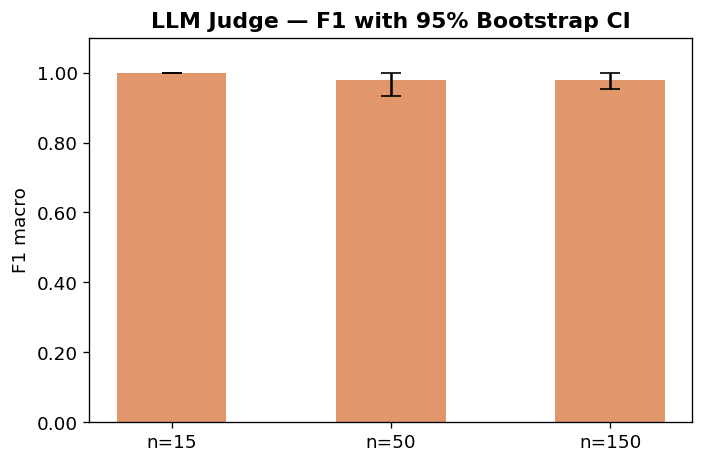

Saved ../figures/fig3_llm_judge_ci.pdf


In [58]:
f1_means = [llm_ci[c]["f1_mean"] for c in cond_names]
yerr_lo  = [llm_ci[c]["f1_mean"] - llm_ci[c]["f1_lo"] for c in cond_names]
yerr_hi  = [llm_ci[c]["f1_hi"]  - llm_ci[c]["f1_mean"] for c in cond_names]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(cond_names))
ax.bar(x, f1_means, color="#DD8452", alpha=0.85, width=0.5)
ax.errorbar(x, f1_means, yerr=[yerr_lo, yerr_hi],
            fmt="none", color="black", capsize=6, lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels(cond_names)
ax.set_ylabel("F1 macro")
ax.set_ylim(0, 1.1)
ax.set_title("LLM Judge — F1 with 95% Bootstrap CI", fontweight="bold")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_llm_judge_ci.pdf", bbox_inches="tight")
plt.show()
print(f"Saved {FIGURES_DIR / 'fig3_llm_judge_ci.pdf'}")

## LaTeX Table Values

In [59]:
# ── Table 1: Continuous methods — separation / AUC / AP ───────────────────────
print("% Table 1: Continuous scoring methods — mean score by label, AUC-ROC, Average Precision")
print("\\begin{tabular}{llrrrrr}")
print("\\toprule")
print("\\textbf{Method} & \\textbf{Cond.} & "
      "\\textbf{Adherent} & \\textbf{Violation} & "
      "\\textbf{Sep.} & \\textbf{AUC} & \\textbf{AP} \\\\")
print("\\midrule")
for i, m in enumerate(CONT_METHODS):
    if i > 0:
        print("\\addlinespace[3pt]")
    first = True
    for cname in cond_names:
        v = cont_results.get(m, {}).get(cname)
        label = m if first else ""
        first = False
        if v is None:
            print(f"{label:20s} & {cname} & \\multicolumn{{5}}{{c}}{{---}} \\\\")
        else:
            print(f"{label:20s} & {cname} & "
                  f"{v['adherent']:.3f} & {v['violation']:.3f} & "
                  f"{v['separation']:+.3f} & {v['auc']:.3f} & {v['ap']:.3f} \\\\")
print("\\bottomrule")
print("\\end{tabular}")
print()

# ── Table 2: Binary classifiers — per-class F1 / macro F1 / κ ─────────────────
print("% Table 2: Binary classifiers — per-class F1, macro F1, Cohen's κ")
print("\\begin{tabular}{llrrrr}")
print("\\toprule")
print("\\textbf{Method} & \\textbf{Cond.} & "
      "\\textbf{F1 adh.} & \\textbf{F1 viol.} & "
      "\\textbf{F1 macro} & \\textbf{$\\kappa$} \\\\")
print("\\midrule")
for i, m in enumerate(BIN_METHODS):
    if i > 0:
        print("\\addlinespace[3pt]")
    first = True
    for cname in cond_names:
        v = bin_results.get(m, {}).get(cname)
        label = m if first else ""
        first = False
        if v is None:
            print(f"{label:12s} & {cname} & \\multicolumn{{4}}{{c}}{{---}} \\\\")
        else:
            print(f"{label:12s} & {cname} & "
                  f"{v['f1_adherent']:.3f} & {v['f1_violation']:.3f} & "
                  f"{v['f1_macro']:.3f} & {v['kappa']:.3f} \\\\")
print("\\bottomrule")
print("\\end{tabular}")
print()

# ── Table 3: LLM Judge — F1 macro + per-class F1 with 95% bootstrap CI ────────
print("% Table 3: LLM Judge — macro F1, per-class F1, Cohen's κ with 95% bootstrap CI (1000 resamples)")
print("\\begin{tabular}{lrlrlrl}")
print("\\toprule")
print("\\textbf{Cond.} & "
      "\\textbf{F1 macro} & \\textbf{95\\% CI} & "
      "\\textbf{F1 adh.} & \\textbf{95\\% CI} & "
      "\\textbf{F1 viol.} & \\textbf{95\\% CI} \\\\")
print("\\midrule")
for cname in cond_names:
    ci = llm_ci[cname]
    print(
        f"{cname} & "
        f"{ci['f1_mean']:.3f} & [{ci['f1_lo']:.3f}, {ci['f1_hi']:.3f}] & "
        f"{ci['f1_adh_mean']:.3f} & [{ci['f1_adh_lo']:.3f}, {ci['f1_adh_hi']:.3f}] & "
        f"{ci['f1_viol_mean']:.3f} & [{ci['f1_viol_lo']:.3f}, {ci['f1_viol_hi']:.3f}] \\\\"
    )
print("\\bottomrule")
print("\\end{tabular}")

% Table 1: Continuous scoring methods — mean score by label, AUC-ROC, Average Precision
\begin{tabular}{llrrrrr}
\toprule
\textbf{Method} & \textbf{Cond.} & \textbf{Adherent} & \textbf{Violation} & \textbf{Sep.} & \textbf{AUC} & \textbf{AP} \\
\midrule
BERTScore            & n=15 & 0.941 & 0.864 & +0.077 & 1.000 & 1.000 \\
                     & n=50 & 0.940 & 0.869 & +0.071 & 1.000 & 1.000 \\
                     & n=150 & 0.941 & 0.868 & +0.073 & 0.995 & 0.994 \\
\addlinespace[3pt]
Cosine               & n=15 & 0.905 & 0.466 & +0.439 & 1.000 & 1.000 \\
                     & n=50 & 0.902 & 0.520 & +0.382 & 0.998 & 0.998 \\
                     & n=150 & 0.877 & 0.497 & +0.380 & 0.994 & 0.990 \\
\addlinespace[3pt]
Mahalanobis          & n=15 & 0.404 & 0.348 & +0.056 & 0.963 & 0.948 \\
                     & n=50 & 0.391 & 0.348 & +0.043 & 0.872 & 0.762 \\
                     & n=150 & 0.391 & 0.350 & +0.041 & 0.856 & 0.761 \\
\addlinespace[3pt]
KL Divergence        & n=15 & 0.860 & 0